# 🌳 Trees, Gini and more!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell.

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside this notebook.
- Answer the follow-up questions in markdown format within this notebook. A few sentences are enough; there is no length requirement.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Some questions and tasks are a bit vague. You are expected to apply techniques we learned in the lectures.
- Submit this notebook to Canvas. Deliver the notebook with its outputs saved; ideally, *restart* the kernel and then *run all*.

Good luck!

---

# 🌴 Problem 1: Fit a decision tree classifier!

### ❗️ The problem
In this first problem, you must load the data and train a decision tree classifier on the provided dataset!

### 📋 Formal requirements
1. **Implementation**:
   - Load `problem1.csv`
   - Analyse the dataset (e.g. the class distribution)
   - Preprocess the training data
   - Train a decision tree classifier
   - Implement the metrics presented in the lectures
2. **Performance**: Achieve at least **0.90** classification accuracy on the test set
3. **Discussion**:
   - What preprocessing do we need to apply before training, and why?
   - Do we need to scale the features?
   - What do you observe in the decision boundary plot before and after preprocessing?
   - What happens when you increase or decrease the depth of the tree?

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE 


In [107]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


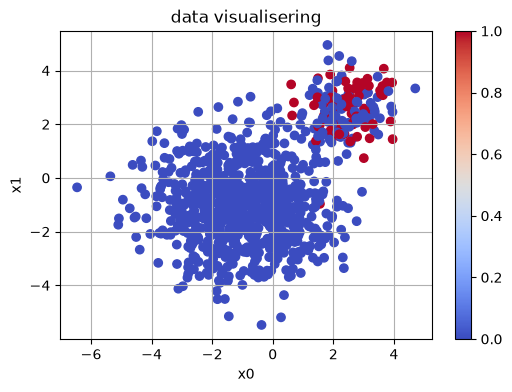

In [108]:
# ====================================
# YOUR CODE GOES HERE: load the data from the problem1.csv file
# ====================================
data = pd.read_csv('problem1.csv')
train = data[data['split']=='train']
test = data[data['split']=='test']

plt.figure(figsize=(6,4))
plt.scatter(train['x0'],train['x1'],c=train['y'],cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('data visualisering')
plt.colorbar()
plt.show()

76
930


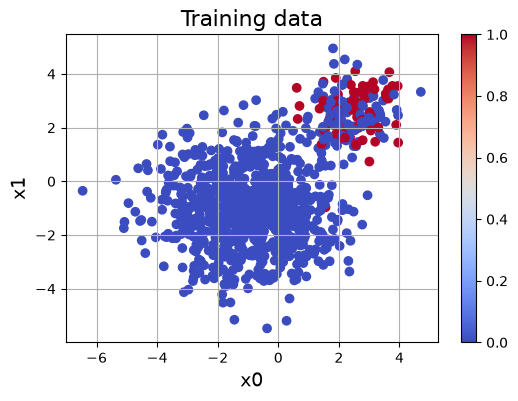

In [109]:
# ====================================
# YOUR CODE GOES HERE: let's analyse the dataset
# ====================================
'''
minority_class = train[train['y']==1]
majority_class = train[train['y']==0]

minority_oversampled = minority_class.sample(
    n=int(len(majority_class)/2),replace=True,random_state=42 
)
balanced_train = pd.concat([majority_class,minority_oversampled])

print((sum_pos/(sum_pos+sum_neg)))'''

sum_pos = (train['y']==1).sum()
sum_neg = (train['y']==0).sum()
print(sum_pos)
print(sum_neg)
# ====================================
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Training data', fontsize=16)
plt.colorbar()
plt.show()

Accuracy: 0.93


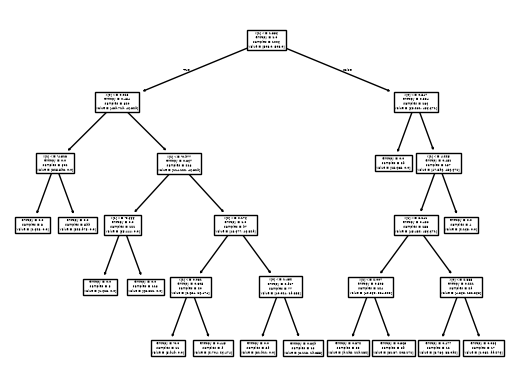

In [110]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import DecisionBoundaryDisplay
X_train = train[['x0', 'x1']]
y_train = train['y']
X_test = test[['x0', 'x1']]
y_test = test['y']

X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

# ====================================
# YOUR CODE GOES HERE
# ====================================
clf = DecisionTreeClassifier(max_depth = 5,random_state=42,class_weight='balanced',criterion='entropy', min_samples_leaf=3)
clf.fit(X_train, y_train)
accuracy = accuracy_score(y_test, clf.predict(X_test))
tree.plot_tree(clf)




# ====================================
print(f'Accuracy: {accuracy:.2f}')



In [111]:
# ====================================
# YOUR CODE GOES HERE: report FPR and TPR alongside other metrics you find relevant (hint: see the lecture notes).
# ====================================
print(classification_report(y_test, clf.predict(X_test)))
y_true = y_test 
y_pred =clf.predict(X_test)

cm = confusion_matrix(y_true,y_pred)
tn, fp, fn, tp = cm.ravel() 
tpr = tp/(tp+fp)
fpr = fp/(tp+tn)
tnr = tn / (tn + fp)   # specificity 
ppv = tp / (tp + fp)  #precision

auc_score  =roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])

# ====================================
print(f"True positive rate: {tpr:.3f}")
print(f"False positive rate: {fpr:.3f}")
print(f"True negative rate (specificity): {tnr:.3f}")
print(f"Positive predictive value (precision): {ppv:.3f}")
print(f"auc_score: {auc_score:.3f}")

              precision    recall  f1-score   support

         0.0       0.98      0.87      0.92       150
         1.0       0.88      0.99      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

True positive rate: 0.881
False positive rate: 0.072
True negative rate (specificity): 0.867
Positive predictive value (precision): 0.881
auc_score: 0.927


### ❓ What preprocessing do we need to apply before training, and why?
We have to acknowledge the severe class imbalance (more than 90% is negative) and account for this. We could have done this by resampling (oversampling the minority or undersampling the majority). I have written code to do this but I commented it out and opted for the easier approach which is simply letting the libraries to the work and putting class_weight = balanced while initiating the tree. 
The reason we have to do this is because if we didnt the tree would have no reason to train. it could just default towards the majority class and get good recall. 

### ❓ Do we need to scale the features?
No, we do not need to scale the features. The tree splits based on thresholds per feature. You would find these to be the same relatively before and after scaling. The only difference being the scaling, but the model is indifferent to this.

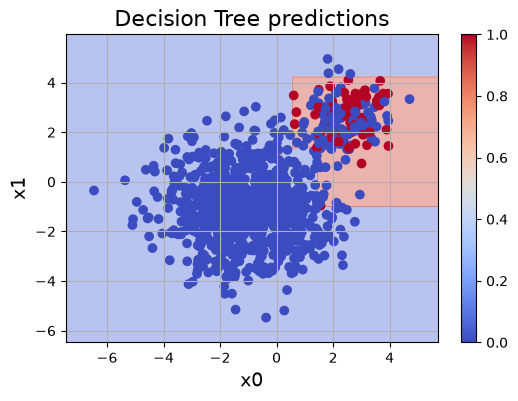

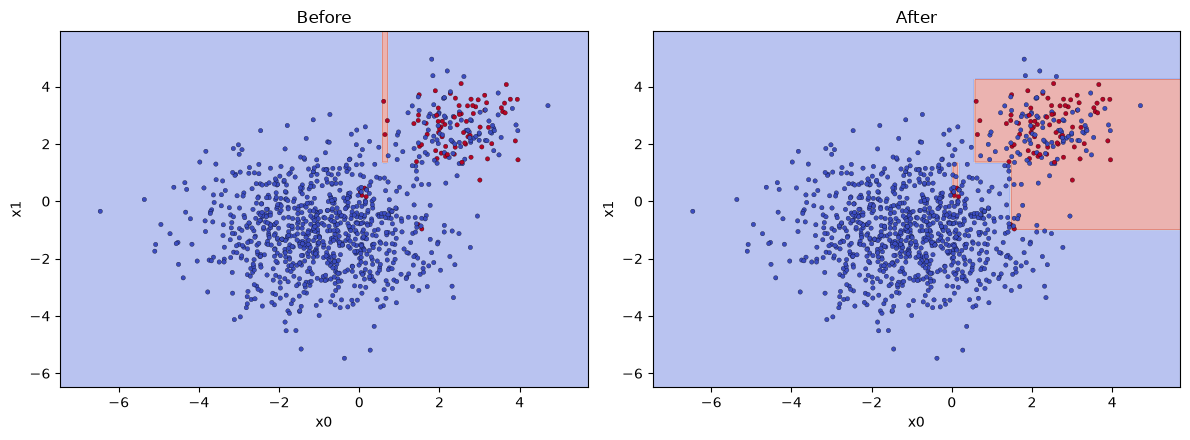

In [112]:
# visualize the decision boundary
x0_min, x0_max = train['x0'].min() - 1, train['x0'].max() + 1
x1_min, x1_max = train['x1'].min() - 1, train['x1'].max() + 1
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.01),
                       np.arange(x1_min, x1_max, 0.01))

grid = pd.DataFrame({'x0': xx0.ravel(), 'x1': xx1.ravel()})
Z =clf.predict(grid)
Z = Z.reshape(xx0.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx0, xx1, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train['x0'], X_train['x1'], c=y_train, cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Decision Tree predictions', fontsize=16)
plt.colorbar()
plt.show()

clf_before = DecisionTreeClassifier(max_depth = 5, random_state = 42,criterion='entropy', min_samples_leaf=3)
clf_before.fit(X_train,y_train)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.05), np.arange(x1_min, x1_max, 0.05))
grid = pd.DataFrame({'x0': xx0.ravel(), 'x1': xx1.ravel()})

for ax, (title, model) in zip(axes, [('Before', clf_before), ('After', clf)]):
    Z = model.predict(grid).reshape(xx0.shape)
    ax.contourf(xx0, xx1, Z, alpha=0.4, cmap='coolwarm')
    ax.scatter(X_train['x0'], X_train['x1'], c=y_train, cmap='coolwarm', s=10, edgecolor='k', linewidth=0.2)
    ax.set_title(title); ax.set_xlabel('x0'); ax.set_ylabel('x1')
plt.tight_layout(); plt.show()



### ❓ What do you observe in the decision boundary plot before and after preprocessing?
Just like I commented in the earlier question, if I dont account for the class balance (before), the model just says everything is negative. The model is pretty much ueseless. The positive decision boundary is just a tiny line. 

### ❓ What happens when you increase or decrease the depth of the tree?
When you increase the tree, you risk overfitting, and decreasing risks underfitting. Looking at the boundary plot, one can see that if you have too deep of a tree, the red zones are more scattered and smaller, in other words increased variance. The opposite happens for decreasing depth.

# 🌴🌴 Problem 2: Predict Viking voyage survivors 🗡️
### ❗️ The problem
You are given a dataset with information about the passengers on Viking voyages.
Your task is to develop a decision tree classifier that predicts which Vikings **survived** a **voyage**.

### 📋 Formal requirements
1. **Implementation**:
   - Do a simple data analysis
   - Preprocess the data 
   - Train a decision tree classifier
   - Report the cross-validation score and the test accuracy
   - Try different split criteria for the decision tree
   - Plot the decision tree
   - Use a boosting technique to improve the accuracy!
   - Use Naïve Bayes to predict whether a single new voyager survives
2. **Performance**: Achieve at least **0.80** classification accuracy on the test set
3. **Discussion**:
   - Analyse the dataset. Are there any features that already predict survival better than a random guess?
   - What is the purpose of cross-validation?
   - Which split criterion do you prefer, and why?
   - What is Gini impurity? Use an example from the decision tree graph you created
   - Which terms of Bayes theorem can you estimate from this dataset, and which ones are difficult?
   - Use Naïve Bayes: does the new voyager have a higher or lower chance of surviving?

Let's start by understanding the dataset.

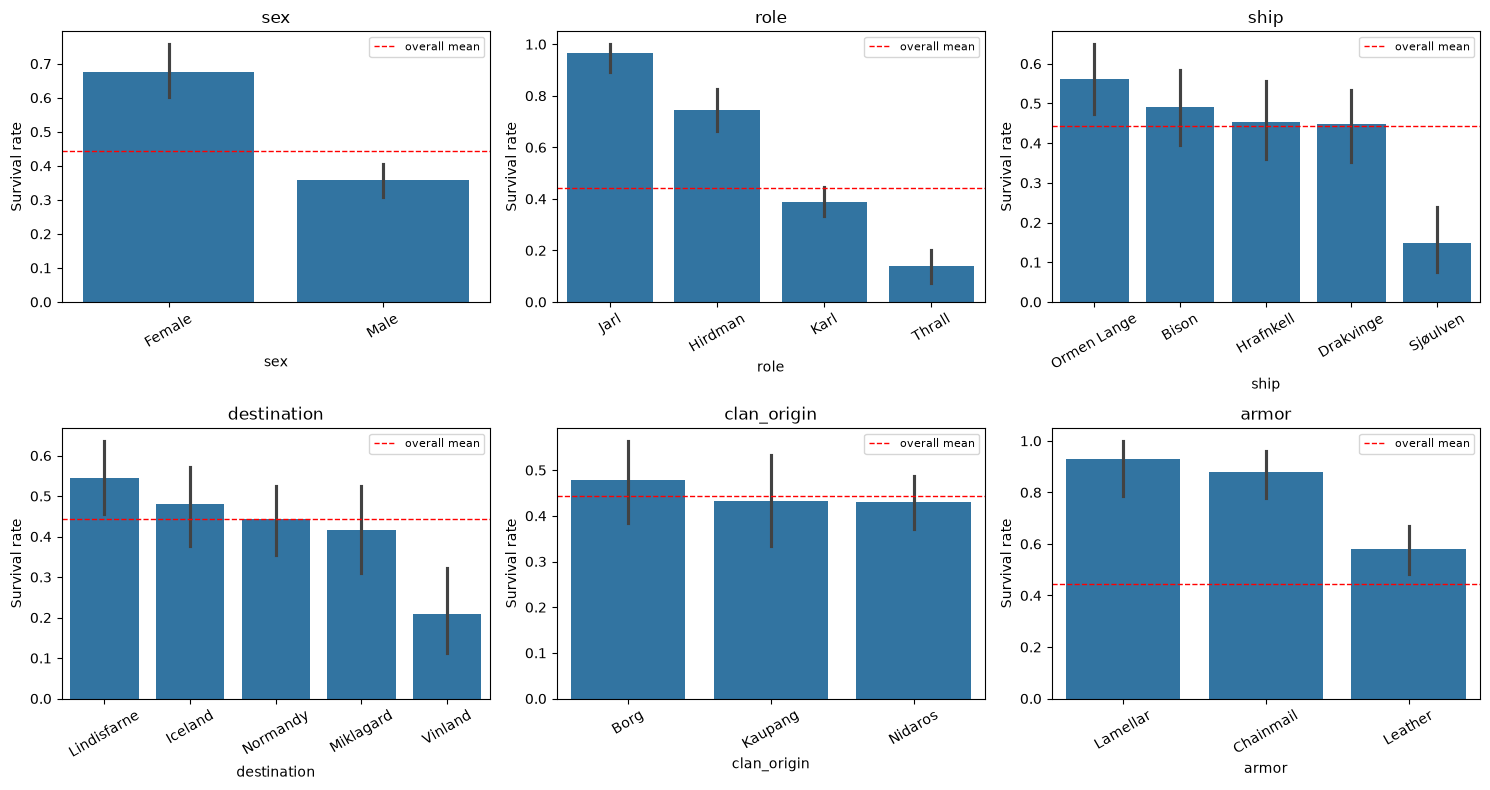

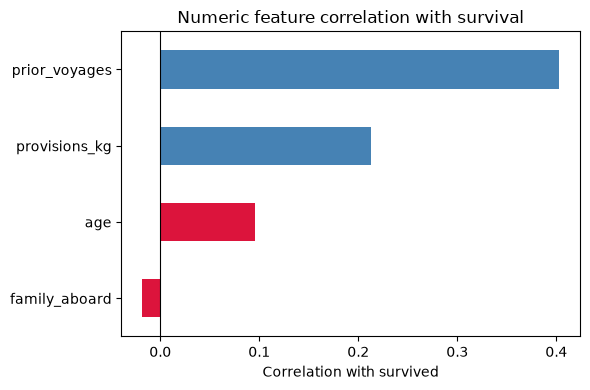

In [124]:
# Let's analyse the dataset
# Make some comments about what you print and what useful information it gives
# ====================================
# YOUR CODE GOES HERE: Let's analyse the dataset!
# ====================================
df = pd.read_csv('problem2.csv')
#df=df.dropna()

df = df.drop(columns=['name'])
df = df.drop(columns=['passenger_id'])

import seaborn as sns


# ---- Categorical features: survival rate per category ----
cat_features = ['sex', 'role', 'ship', 'destination', 'clan_origin', 'armor']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, cat_features):
    order = df.groupby(col)['survived'].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y='survived', order=order, ax=ax)
    ax.axhline(df['survived'].mean(), color='red', linestyle='--', linewidth=1, label='overall mean')
    ax.set_title(col)
    ax.set_ylabel('Survival rate')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ---- Numeric features: correlation with survived ----
num_features = ['age', 'provisions_kg', 'family_aboard', 'prior_voyages']
corrs = df[num_features + ['survived']].corr()['survived'].drop('survived').sort_values()

plt.figure(figsize=(6, 4))
corrs.plot(kind='barh', color=['crimson' if c < 0.1 else 'steelblue' for c in corrs])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with survived')
plt.title('Numeric feature correlation with survival')
plt.tight_layout()
plt.show()


# ====================================



df['armor']=df['armor'].fillna('Unknown')

#
df['age']=df['age'].fillna(df['age'].median())
df['age_group'] = pd.cut(df['age'], bins = [0,12,18,30,50,100], labels = ['child','teen','young_adult','adult','elder'])
df = df.drop(columns=['age'])


df['provisions_group'] = pd.cut(
    df['provisions_kg'],
    bins=[0, 5, 15, 30, 60, 1000],
    labels=['minimal', 'low', 'moderate', 'well_provisioned', 'very_well_provisioned']
)
df = df.drop(columns='provisions_kg')



df['clan_origin']=df['clan_origin'].fillna('Unknown')
df = pd.get_dummies(df,dtype=int)

df_X = df.drop(columns=['survived'])




### ❓ Are there any features that already predict survival better than a random guess?
Considering our data has a survival rate of .44, we just need a feature to be better than this. I have plotted the survival rate for the categorical features. Role, sex and armor clears the .44 surival rate by good margin, so these features seem to predict better than just guessing. 
The numeric features shows some correlation between survival and prior voyages and provisions. Age, family, clan origin, destination and ship seem to be equivalent of guessing at random. 

In [114]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

target = 'survived'
# ====================================
# YOUR CODE GOES HERE: Train the model:)
# ====================================
X = df_X
y=df[target]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2, random_state=42, stratify=y)

model = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'class_weight': [None, 'balanced']
    
}
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=10,
    scoring='accuracy',
    
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)



# ====================================

print("Training accuracy:", best_model.score(X_train, y_train))
print("CV accuracy:", grid_search.best_score_)
print("Test accuracy:", best_model.score(X_test, y_test))

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 20}
0.7875
Training accuracy: 0.825
CV accuracy: 0.7875
Test accuracy: 0.76


### ❓ What is the purpose of cross validation?
the purpose of cross validation is to reduce variance. We use different train/val splits to make sure we arent just overfitting our model to a specific set of training data. 

In [115]:
# Compare the different split criteria
# ====================================
# YOUR CODE GOES HERE: try the different split criteria (gini, entropy, log_loss)
# and report the cross-validation and test accuracy for each
# ====================================


### ❓ Try different DecisionTreeClassifier criteria, report what accuracy you get. Which criterion do you prefer?
This is excactly what I did when gridsearching. I found the best model to use 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 20. This got a test accuracy of .76 and CV accuracy of .7875. Not too bad but we can do better with boosting. 

[Text(0.5, 0.9, 'x[1] <= 2.5\ngini = 0.5\nsamples = 400\nvalue = [200.0, 200.0]'),
 Text(0.2777777777777778, 0.7, 'x[3] <= 0.5\ngini = 0.472\nsamples = 281\nvalue = [169.369, 104.494]'),
 Text(0.3888888888888889, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'x[17] <= 0.5\ngini = 0.424\nsamples = 82\nvalue = [26.126, 59.551]'),
 Text(0.1111111111111111, 0.3, 'x[12] <= 0.5\ngini = 0.37\nsamples = 73\nvalue = [18.919, 58.427]'),
 Text(0.05555555555555555, 0.1, 'gini = 0.285\nsamples = 63\nvalue = [11.712, 56.18]'),
 Text(0.16666666666666666, 0.1, 'gini = 0.362\nsamples = 10\nvalue = [7.207, 2.247]'),
 Text(0.2222222222222222, 0.3, 'gini = 0.233\nsamples = 9\nvalue = [7.207, 1.124]'),
 Text(0.3888888888888889, 0.5, 'x[5] <= 0.5\ngini = 0.364\nsamples = 199\nvalue = [143.243, 44.944]'),
 Text(0.3333333333333333, 0.3, 'x[22] <= 0.5\ngini = 0.343\nsamples = 195\nvalue = [143.243, 40.449]'),
 Text(0.2777777777777778, 0.1, 'gini = 0.322\nsamples = 190\nvalue = [142.342, 35.955]'),
 Text(0.38

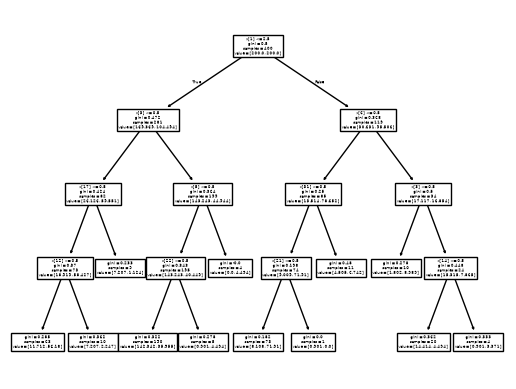

In [116]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ====================================
# YOUR CODE GOES HERE: Plot the decision tree nodes!
# ====================================
plot_tree(best_model)

### ❓ What is Gini? Use an example from the decision tree graph you created.
Gini is a metric to measure the mix of classes inside a dataset. It calculates the probability that a randomly chosen item in a group would be wrongfully labeled if it was labeled randomly based on class distribution. 

## Improving the results with boosting 🚀

In [117]:
from sklearn.ensemble import AdaBoostClassifier
# ====================================
# YOUR CODE GOES HERE: Use AdaBoostClassifier to get even better results!
# ====================================



stump = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_model = AdaBoostClassifier(
    estimator=stump,
    n_estimators=100,
    learning_rate=0.3,
    random_state=42
)
ada_model.fit(X_train, y_train)


ada_cv_scores = cross_val_score(ada_model, X_train, y_train, cv=5, scoring='accuracy')
y_pred_ada = ada_model.predict(X_test)

ada_acc = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost CV Accuracy: {ada_cv_scores.mean():.3f} ± {ada_cv_scores.std():.3f}")
print(f"AdaBoost test accuracy: {ada_acc:.4f}")

AdaBoost CV Accuracy: 0.812 ± 0.038
AdaBoost test accuracy: 0.8000


### ❓ Try estimating the terms of Bayes theorem using this dataset. What terms can you estimate and which ones are difficult and why?
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Survival (P(A)/prior) is easy to estimate. Just take the mean of the column, since its binary data. The likelihood, P(B|A) is difficult to estimate because the features arent necesseraly independent, and its a combination of many features. Its not like we are explicitly going to find each combination of 10 features in the data set. That is where the naive part comes in, we assume independence and just multiply the conditional likelihood for each feature P(B_i|A). That is easy to do. However we still have to process the data a bit. For instance we need to bin the continous features like provisions kg and age. We also have to consider the case that we receive a value which doesnt exist in the data. if we dont have data on people with x prior voyages this will just give P(B_i|A)=0, and then that makes everything 0. We fix this by doing so called add-one smoothing. instead of count(value, class) / count(class), we use (count(value, class) + 1) / (count(class) + k). 
Calculating P(B) is also difficult since it is a combination of features, however we dont need it. Since we are only dealing with A=1 or A=0, and P(A|B) has P(B) in the denominator anyway. We just compare these relative to each other to find the posterior. 

In [118]:
# ====================================
# YOUR CODE GOES HERE: estimate the terms of Bayes theorem you can
# ====================================
#I create a new dataframe 
df=pd.read_csv('problem2.csv')



df = df.drop(columns=['name'])
df = df.drop(columns=['passenger_id'])

df['armor']=df['armor'].fillna('Unknown')


df['age']=df['age'].fillna(df['age'].median())
df['age_group'] = pd.cut(df['age'], bins = [0,12,18,30,50,100], labels = ['child','teen','young_adult','adult','elder'])



df['provisions_group'] = pd.cut(
    df['provisions_kg'],
    bins=[0, 5, 15, 30, 60, 1000],
    labels=['minimal', 'low', 'moderate', 'well_provisioned', 'very_well_provisioned']
)




df['clan_origin']=df['clan_origin'].fillna('Unknown')



print(df.columns)
print(df['survived'].value_counts(normalize=True))

P_survival = (df['survived'].value_counts(normalize=True))[1]
P_dying = 1-P_survival


def P_B_given_A(survived, feature,value):
    subset = df[df['survived']==survived]
    count = (subset[feature]==value).sum()
    k = df[feature].nunique()
    return (count+1)/(subset[feature].size+k)

def naive_likelihood(features,survived):
    likelihood = 1
    for feature, value in features.items():
        likelihood*=P_B_given_A(survived, feature, value)
    return likelihood 





    
    

#
    

Index(['sex', 'age', 'role', 'ship', 'destination', 'clan_origin', 'armor',
       'provisions_kg', 'family_aboard', 'prior_voyages', 'survived',
       'age_group', 'provisions_group'],
      dtype='str')
survived
0    0.556
1    0.444
Name: proportion, dtype: float64


### ❓ Use Naïve Bayes. Does Endre have a higher or lower chance of surviving than dying a voyage?
Using our naive bayes model I would say his survival odds are pretty good. I would give him about a 96% chance of survival.


A voyager named **Endre** is about to set sail. This is what we know about him:

| Feature | Value |
| --- | --- |
| `sex` | Male |
| `age` | 25 |
| `role` | Hirdman |
| `ship` | Drakvinge |
| `destination` | Normandy |
| `clan_origin` | Nidaros |
| `armor` | Chainmail |
| `provisions_kg` | 49 |
| `family_aboard` | 2 |
| `prior_voyages` | 12 |

Does he have a **higher or lower** chance of surviving the voyage?

In [119]:
# ====================================
# YOUR CODE GOES HERE: Naïve Bayes
# You can either do this by hand or with code.
# Do not import libraries.
# ====================================

#could make a class instance for a person and have a mapping function for the
#binned values to initiate them automatically, but oh well
Endre = {
    'sex':'Male',
    'age_group': 'young_adult',
    'role' : 'Hirdman',
    'ship':'Drakvinge',
    'destination':'Normandy',
    'clan_origin':'Nidaros',
    'armor':'Chainmail',
    'provisions_group':'well_provisioned',
    'family_aboard':2,
    'prior_voyages':12
}
print(Endre.items())
likelihood_surival = naive_likelihood(Endre, 1)
likelihood_death = naive_likelihood(Endre, 0)

naive_survival_prob = (likelihood_surival*P_survival)/(likelihood_surival*P_survival+likelihood_death*P_dying)
naive_death_prob = (likelihood_death*P_dying)/(likelihood_surival*P_survival+likelihood_death*P_dying)
print(naive_survival_prob)
print(naive_death_prob)


dict_items([('sex', 'Male'), ('age_group', 'young_adult'), ('role', 'Hirdman'), ('ship', 'Drakvinge'), ('destination', 'Normandy'), ('clan_origin', 'Nidaros'), ('armor', 'Chainmail'), ('provisions_group', 'well_provisioned'), ('family_aboard', 2), ('prior_voyages', 12)])
0.9635913289755358
0.03640867102446416
